In [ ]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys 
import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
perm_20 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm20_nep20.pt")
perm_40 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm40_nep20.pt")
perm_60 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm60_nep20.pt")
perm_80 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm80_nep20.pt")
all_training_runs = [perm_20, perm_40, perm_60, perm_80]

In [9]:
# check that training alphabets have no overlap with new alphabets:
df20 = pd.read_csv("../data/all_transformations_study1_copy_perm20/test.csv")
df40 = pd.read_csv("../data/all_transformations_study1_copy_perm40/test.csv")
df60 = pd.read_csv("../data/all_transformations_study1_copy_perm60/test.csv")
df80 = pd.read_csv("../data/all_transformations_study1_copy_perm80/test.csv")

all_training_alphabets = set(list(df20.alphabet.unique()) + list(df40.alphabet.unique()) + list(df60.alphabet.unique()) + list(df80.alphabet.unique()))

df_new_alphs = pd.read_csv("../data/all_transformations_study1_new_alphabets/test.csv")
# only overlapping alphabet should be the standard alphabet:
all_training_alphabets & set(df_new_alphs.alphabet.unique())

{'a b c d e f g h i j k l m n o p q r s t u v w x y z'}

In [10]:
accs_new_alphabets = pd.DataFrame(columns=["batching_method", "accuracy in-dist", "accuracy out-of-dist"])
for i, cp in enumerate(all_training_runs):
    test_new_alph = cp.load_dataloaders("../data/all_transformations_study1_new_alphabets", use_datasets=["test"], val_batch_size=10_000, verbose=False)[0]
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    test_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    accs_new_alphabets.loc[i,:] = [cp.train_config.batching_method, test_acc_in, test_acc_out_of]
accs_new_alphabets.round(3)

Predicting:   0%|          | 0/359 [00:00<?, ?it/s]c:\Users\13579681\AppData\Local\anaconda3\envs\mlc-ls\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
Predicting: 370it [06:20,  1.03s/it]                         
Predicting: 370it [05:25,  1.14it/s]                         
Predicting: 370it [06:50,  1.11s/it]                         
Predicting: 370it [10:22,  1.68s/it]                         


,batching_method,accuracy in-dist,accuracy out-of-dist
0,alphabet,0.3045,0.034993
1,alphabet,0.526952,0.062103
2,alphabet,0.567022,0.053259
3,alphabet,0.704087,0.071332


In [ ]:
accs_new_alphabets["perm. alphabets in training"] = [20,40,60,80]
accs_new_alphabets["new_alphabets"] = True
accs_new_alphabets.drop(columns=["batching_method"], inplace=True)

In [17]:
accs_new_alphabets

,accuracy in-dist,accuracy out-of-dist,perm. alphabets in training,new_alphabets
0,0.3045,0.034993,20,True
1,0.526952,0.062103,40,True
2,0.567022,0.053259,60,True
3,0.704087,0.071332,80,True


In [ ]:
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["loss"] = round(train_run.best_val_loss, 3)
    data[i]["accuracy in-dist"] = round(np.max([x["in"] for x in train_run.val_acc_hist]), 3)
    data[i]["accuracy out-of-dist"] = round(np.max([x["out-of"] for x in train_run.val_acc_hist]), 3)
df = pd.DataFrame(data)
df["perm. alphabets in training"] = [20,40,60,80]

In [24]:
df

,filename_model,dir_model,dir_data,batch_size,batching_method,query_first,nepochs,lr,lr_end_factor,lr_warmup,...,nlayers_decoder,nhead,dropout_p,ff_mult,activation,loss,accuracy in-dist,accuracy out-of-dist,perm. alphabets in training,new_alphabets
0,MLC_batchalph_dallstudy1_copy_perm20_nep20.pt,models,data/all_transformations_study1_copy_perm20,32,alphabet,False,20,0.001,0.05,True,...,3,8,0.1,4,gelu,0.691,0.900,0.100,20,False
1,MLC_batchalph_dallstudy1_copy_perm40_nep20.pt,models,data/all_transformations_study1_copy_perm40,32,alphabet,False,20,0.001,0.05,True,...,3,8,0.1,4,gelu,0.645,0.949,0.126,40,False
2,MLC_batchalph_dallstudy1_copy_perm60_nep20.pt,models,data/all_transformations_study1_copy_perm60,32,alphabet,False,20,0.001,0.05,True,...,3,8,0.1,4,gelu,0.601,0.936,0.093,60,False
3,MLC_batchalph_dallstudy1_copy_perm80_nep20.pt,models,data/all_transformations_study1_copy_perm80,32,alphabet,False,20,0.001,0.05,True,...,3,8,0.1,4,gelu,0.642,0.947,0.138,80,False


In [26]:
# Merge the two DataFrames on the 'perm. alphabets in training' column
df = df[["accuracy in-dist","accuracy out-of-dist","perm. alphabets in training", "new_alphabets"]]

In [27]:
all_accs = pd.concat([df, accs_new_alphabets])

In [28]:
all_accs

,accuracy in-dist,accuracy out-of-dist,perm. alphabets in training,new_alphabets
0,0.9,0.1,20,False
1,0.949,0.126,40,False
2,0.936,0.093,60,False
3,0.947,0.138,80,False
0,0.3045,0.034993,20,True
1,0.526952,0.062103,40,True
2,0.567022,0.053259,60,True
3,0.704087,0.071332,80,True


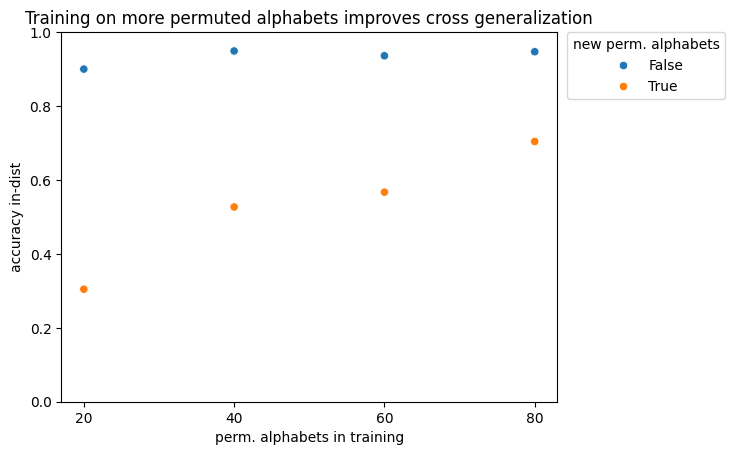

In [42]:
_ = sns.scatterplot(all_accs, x="perm. alphabets in training", y="accuracy in-dist", hue="new_alphabets")
_ = plt.ylim((0,1))
_ = plt.xticks([20, 40, 60, 80])
_ = plt.legend(title="new perm. alphabets", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
_ = plt.title("Training on more permuted alphabets improves cross generalization")